<a href="https://colab.research.google.com/github/muvunyiy77-a11y/Day-One/blob/main/BIT8321_Makeup%20CAT2_Juistin%20Mugisha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIT8321 – Machine Learning and Artificial Intelligence
## Make-up CAT and Assignments 1 & 2 — Rwanda Health-Supply Intelligence System

1. **JUSTIN MUGISHA**
2. **Registration Number:** _BBICTR/2025/_
3. **Programme:** BBICT Jan 2025 Evening

This notebook is organised into three clearly-labelled parts that match the assessment brief:

- **Part A — Assignment 1: Demand Prediction (Regression)**
- **Part B — Assignment 2: Stockout-Risk Classification**
- **Part C — Make-up CAT: PCA, Clustering and Integration**

A single synthetic dataset (≥300 observations, generated with a fixed random seed) is used
throughout so that the regression, classification and clustering sections are consistent
with one another. All preprocessing (imputation, encoding, scaling) is fit **only on the
training data** in every section to avoid data leakage.


## 0. Setup and Reproducibility
Imports and a fixed random seed used everywhere below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', None)


## 0.1 Dataset Generation (synthetic, with documented assumptions)

Real, facility-level medicine-demand data for Rwandan pharmacies/hospitals is not publicly
available at the granularity this assignment needs, so a **synthetic dataset is generated**.
The generation code below is included in full, and the assumptions are stated explicitly:

- 600 observations across 4 districts (Kigali, Huye, Musanze, Rubavu) and 3 facility types
  (Hospital, Health Centre, Pharmacy), consistent with the brief.
- `weekly_patient_count` depends on facility type (hospitals see more patients) and district
  (Kigali is busiest), with random facility-level variation.
- `previous_week_demand` and `weekly_medicine_demand` are generated as a function of patient
  volume and medicine category (e.g. antimalarials have higher demand than vaccines), plus
  rainfall (malaria-related demand rises with rain) and random noise — this keeps the
  regression task realistic (learnable signal + noise, not a deterministic formula).
- `opening_stock` and `deliveries_received` are generated from demand with noise and a
  penalty for `supplier_delay_days`, so that a facility can plausibly be understocked.
- `stockout_risk` is derived from a shortfall ratio (demand vs. available stock), supplier
  delay and transport distance, then thresholded so that roughly the top ~38% of risk
  scores are labelled `High` — this creates a **realistic, moderate class imbalance**
  rather than a perfectly balanced 50/50 target.
- A small amount (3%) of missing values is injected into three numeric columns to make the
  "handle missing values" requirement meaningful rather than trivial.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N = 600  # observations, well above the 300 minimum

districts = ['Kigali', 'Huye', 'Musanze', 'Rubavu']
facility_types = ['Hospital', 'Health Centre', 'Pharmacy']
medicine_categories = ['Antimalarials', 'Antibiotics', 'Analgesics', 'Vaccines', 'Chronic Disease Meds']

district_weight = {'Kigali': 0.40, 'Huye': 0.22, 'Musanze': 0.20, 'Rubavu': 0.18}
district = np.random.choice(districts, size=N, p=[district_weight[d] for d in districts])
facility_type = np.random.choice(facility_types, size=N, p=[0.25, 0.45, 0.30])
medicine_category = np.random.choice(medicine_categories, size=N)

# Base patient volume depends on facility type and district (Kigali busier)
base_patients = {'Hospital': 900, 'Health Centre': 350, 'Pharmacy': 150}
district_multiplier = {'Kigali': 1.3, 'Huye': 1.0, 'Musanze': 0.95, 'Rubavu': 0.9}

weekly_patient_count = np.array([
    max(5, np.random.normal(base_patients[ft] * district_multiplier[d], base_patients[ft] * 0.2))
    for ft, d in zip(facility_type, district)
]).round().astype(int)

supplier_delay_days = np.clip(np.random.poisson(3, N) + np.random.normal(0, 1, N), 0, 20).round(1)
rainfall_mm = np.clip(np.random.gamma(2, 25, N), 0, 300).round(1)
transport_distance_km = np.clip(np.random.exponential(15, N) + 2, 1, 180).round(1)

# Demand driven mainly by patient count and medicine category, with noise
category_factor = {'Antimalarials': 1.2, 'Antibiotics': 1.0, 'Analgesics': 0.8,
                    'Vaccines': 0.5, 'Chronic Disease Meds': 0.9}
cat_f = np.array([category_factor[c] for c in medicine_category])

previous_week_demand = np.clip(
    weekly_patient_count * cat_f * np.random.normal(0.55, 0.08, N)
    + rainfall_mm * 0.05, 5, None
).round().astype(int)

weekly_medicine_demand = np.clip(
    previous_week_demand * np.random.normal(1.03, 0.10, N)
    + weekly_patient_count * cat_f * 0.05
    + rainfall_mm * 0.08
    - supplier_delay_days * 0.5,
    5, None
).round().astype(int)

opening_stock = np.clip(
    previous_week_demand * np.random.normal(0.9, 0.25, N), 0, None
).round().astype(int)

deliveries_received = np.clip(
    weekly_medicine_demand * np.random.normal(0.85, 0.2, N) - supplier_delay_days * 3,
    0, None
).round().astype(int)

# Stockout risk: High when available stock is well below actual demand
available_stock = opening_stock + deliveries_received
shortfall_ratio = (weekly_medicine_demand - available_stock) / weekly_medicine_demand
risk_score = (
    0.5 * shortfall_ratio
    + 0.02 * supplier_delay_days
    + 0.01 * transport_distance_km / 10
    + np.random.normal(0, 0.08, N)
)
stockout_risk = np.where(risk_score > np.quantile(risk_score, 0.62), 'High', 'Low')

df = pd.DataFrame({
    'facility_type': facility_type,
    'district': district,
    'medicine_category': medicine_category,
    'weekly_patient_count': weekly_patient_count,
    'previous_week_demand': previous_week_demand,
    'opening_stock': opening_stock,
    'deliveries_received': deliveries_received,
    'supplier_delay_days': supplier_delay_days,
    'rainfall_mm': rainfall_mm,
    'transport_distance_km': transport_distance_km,
    'weekly_medicine_demand': weekly_medicine_demand,
    'stockout_risk': stockout_risk
})

# Inject a small amount of realistic missingness (not in the target)
for col in ['supplier_delay_days', 'rainfall_mm', 'weekly_patient_count']:
    miss_idx = df.sample(frac=0.03, random_state=RANDOM_SEED).index
    df.loc[miss_idx, col] = np.nan

In [3]:
df.head()

,facility_type,district,medicine_category,weekly_patient_count,previous_week_demand,opening_stock,deliveries_received,supplier_delay_days,rainfall_mm,transport_distance_km,weekly_medicine_demand,stockout_risk
0,Hospital,Kigali,Chronic Disease Meds,1050.0,654,656,471,1.8,71.5,11.6,641,Low
1,Health Centre,Rubavu,Vaccines,384.0,94,97,90,6.2,60.4,10.9,110,Low
2,Hospital,Musanze,Chronic Disease Meds,824.0,544,503,623,4.6,101.0,2.1,631,Low
3,Hospital,Huye,Analgesics,764.0,312,87,404,5.1,100.5,27.7,356,High
4,Hospital,Kigali,Antimalarials,1267.0,675,329,340,1.4,26.5,8.7,822,High


---
# PART A — ASSIGNMENT 1: DEMAND PREDICTION (20 MARKS)

## A.1 Problem framing and data dictionary (3 marks)

**Task type:** supervised **regression**.

- **Target (y):** `weekly_medicine_demand` — a continuous count of medicine units demanded
  by a facility in a week.
- **Feature matrix (X):** all other facility/operational variables (excludes the target and
  the classification target `stockout_risk`, which is a *different* label and would leak
  information about demand if included as a feature).

### Data dictionary

| Variable | Type | Description |
|---|---|---|
| facility_type | Categorical | Hospital / Health Centre / Pharmacy |
| district | Categorical | Kigali / Huye / Musanze / Rubavu |
| medicine_category | Categorical | Class of medicine being tracked |
| weekly_patient_count | Numeric | Patients seen at the facility that week |
| previous_week_demand | Numeric | Units demanded in the prior week |
| opening_stock | Numeric | Stock on hand at the start of the week |
| deliveries_received | Numeric | Units delivered by suppliers during the week |
| supplier_delay_days | Numeric | Average delay of supplier deliveries (days) |
| rainfall_mm | Numeric | Weekly rainfall (proxy for malaria-season demand) |
| transport_distance_km | Numeric | Distance from the regional distribution hub |
| weekly_medicine_demand | Numeric (target, regression) | Units demanded that week |
| stockout_risk | Categorical (target, classification) | High / Low risk of stockout |


In [4]:
feature_cols = [c for c in df.columns if c not in ['weekly_medicine_demand', 'stockout_risk']]
target_reg = 'weekly_medicine_demand'
print('Feature matrix X columns:', feature_cols)
print('Regression target y:', target_reg)


Feature matrix X columns: ['facility_type', 'district', 'medicine_category', 'weekly_patient_count', 'previous_week_demand', 'opening_stock', 'deliveries_received', 'supplier_delay_days', 'rainfall_mm', 'transport_distance_km']
Regression target y: weekly_medicine_demand


## A.2 Data inspection and preparation (5 marks)

Shape, data types, descriptive statistics, missing values and outliers, followed by
encoding, scaling and a reproducible train/test split. Preprocessing is wrapped in a
`ColumnTransformer` **inside a Pipeline**, so it is fit only on the training fold — this is
what prevents data leakage.


In [5]:
print('Shape:', df.shape)
print()
print(df.dtypes)


Shape: (600, 12)

facility_type              object
district                   object
medicine_category          object
weekly_patient_count      float64
previous_week_demand        int64
opening_stock               int64
deliveries_received         int64
supplier_delay_days       float64
rainfall_mm               float64
transport_distance_km     float64
weekly_medicine_demand      int64
stockout_risk              object
dtype: object


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
facility_type,600,3,Health Centre,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,600,4,Kigali,244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medicine_category,600,5,Vaccines,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekly_patient_count,582.0,NaN,NaN,NaN,489.084192,356.068509,61.0,207.25,384.5,707.75,1561.0
previous_week_demand,600.0,NaN,NaN,NaN,237.835,194.498922,27.0,95.75,173.5,298.0,1151.0
opening_stock,600.0,NaN,NaN,NaN,211.52,187.529131,12.0,83.0,152.5,277.0,1140.0
deliveries_received,600.0,NaN,NaN,NaN,220.133333,197.521265,0.0,77.0,159.5,285.25,1205.0
supplier_delay_days,582.0,NaN,NaN,NaN,2.975945,1.827973,0.0,1.6,2.9,4.2,10.1
rainfall_mm,582.0,NaN,NaN,NaN,49.193299,34.04542,0.8,23.425,41.85,66.0,234.4
transport_distance_km,600.0,NaN,NaN,NaN,16.157167,13.927853,2.0,6.275,12.0,20.525,104.3


In [7]:
print('Missing values per column:')
print(df.isna().sum())


Missing values per column:
facility_type              0
district                   0
medicine_category          0
weekly_patient_count      18
previous_week_demand       0
opening_stock              0
deliveries_received        0
supplier_delay_days       18
rainfall_mm               18
transport_distance_km      0
weekly_medicine_demand     0
stockout_risk              0
dtype: int64


/tmp/ipykernel_507/378063623.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(df[['weekly_patient_count', 'previous_week_demand']].dropna().values,


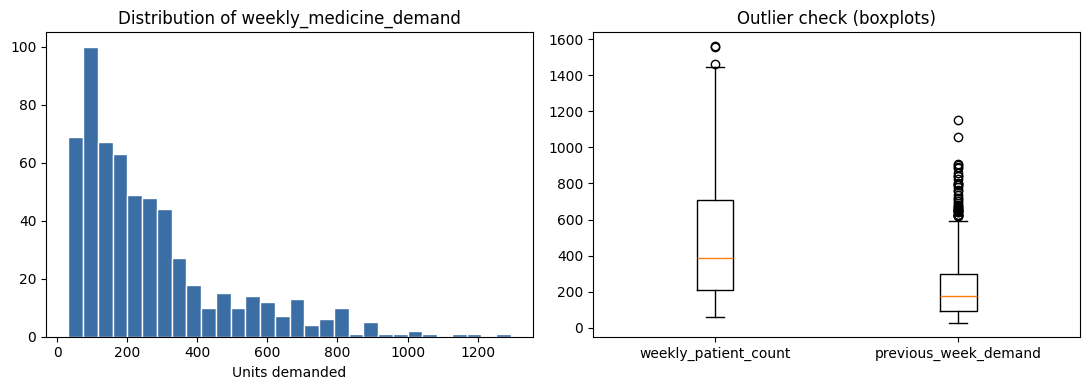

In [8]:
# EDA plot 1: distribution of the regression target + outlier check via boxplot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['weekly_medicine_demand'], bins=30, color='#3b6ea5', edgecolor='white')
axes[0].set_title('Distribution of weekly_medicine_demand')
axes[0].set_xlabel('Units demanded')

axes[1].boxplot(df[['weekly_patient_count', 'previous_week_demand']].dropna().values,
                labels=['weekly_patient_count', 'previous_week_demand'])
axes[1].set_title('Outlier check (boxplots)')
plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df[feature_cols].copy()
y = df[target_reg].copy()

num_cols = ['weekly_patient_count', 'previous_week_demand', 'opening_stock',
            'deliveries_received', 'supplier_delay_days', 'rainfall_mm', 'transport_distance_km']
cat_cols = ['facility_type', 'district', 'medicine_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# Numeric: median-impute missing values, then standardize (mean 0, sd 1)
# Categorical: mode-impute, then one-hot encode
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                       ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (480, 10) Test shape: (120, 10)


**Note on leakage prevention:** `preprocessor` is only ever `.fit()` as part of a
Pipeline called on `X_train`; when we call `.transform()`/`.predict()` on `X_test`, the
scaler mean/variance and the one-hot categories learned on the training set are reused,
never re-fit on test data.

## A.3 Train and compare regression models (8 marks)

`LinearRegression`, `Ridge`, `Lasso` and `PLSRegression` are trained on the same
preprocessed features. MAE, RMSE and R² are reported for both train and test sets in one
comparison table, followed by a predicted-vs-actual plot.


In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_SEED),
    'Lasso': Lasso(alpha=0.1, random_state=RANDOM_SEED, max_iter=10000),
    'PLSRegression': PLSRegression(n_components=5)
}

reg_results = []
reg_predictions = {}
reg_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    reg_pipes[name] = pipe

    pred_train = pipe.predict(X_train).ravel()
    pred_test = pipe.predict(X_test).ravel()
    reg_predictions[name] = pred_test

    reg_results.append({
        'Model': name,
        'Train_MAE': mean_absolute_error(y_train, pred_train),
        'Test_MAE': mean_absolute_error(y_test, pred_test),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, pred_train)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test, pred_test)),
        'Train_R2': r2_score(y_train, pred_train),
        'Test_R2': r2_score(y_test, pred_test),
    })

reg_results_df = pd.DataFrame(reg_results).round(3)
reg_results_df


,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2
0,LinearRegression,19.689,16.640,31.676,30.635,0.979,0.980
1,Ridge,19.740,16.635,31.716,30.694,0.979,0.980
2,Lasso,19.650,16.507,31.688,30.527,0.979,0.981
3,PLSRegression,23.656,21.942,36.497,37.621,0.972,0.971


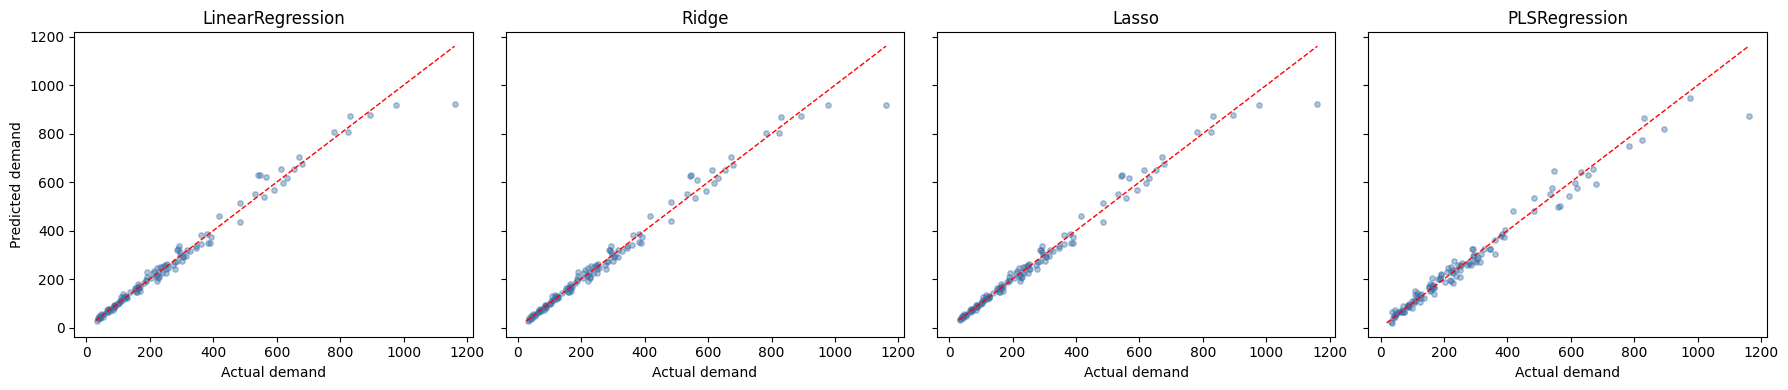

In [11]:
# Predicted vs Actual plot (test set) for every model
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
for ax, (name, pred) in zip(axes, reg_predictions.items()):
    ax.scatter(y_test, pred, alpha=0.4, s=15, color='#3b6ea5')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('Actual demand')
axes[0].set_ylabel('Predicted demand')
plt.tight_layout()
plt.show()


## A.4 Model selection and explanation (4 marks)

The cell below prints the comparison table again and automatically identifies the model
with the best test R² and the smallest train/test gap, which is the practical basis for
model selection.


In [12]:
reg_results_df['Train_Test_R2_Gap'] = (reg_results_df['Train_R2'] - reg_results_df['Test_R2']).round(3)
best_model_name = reg_results_df.sort_values('Test_R2', ascending=False).iloc[0]['Model']
print(reg_results_df[['Model', 'Test_R2', 'Train_Test_R2_Gap', 'Test_RMSE']])
print()
print(f'Best-performing model on held-out test data: {best_model_name}')


              Model  Test_R2  Train_Test_R2_Gap  Test_RMSE
0  LinearRegression    0.980             -0.001     30.635
1             Ridge    0.980             -0.001     30.694
2             Lasso    0.981             -0.002     30.527
3     PLSRegression    0.971              0.001     37.621

Best-performing model on held-out test data: Lasso


**Interpretation (fill in with your own numbers from the table above once you run the notebook):**

- **Coefficient shrinkage:** Ridge and Lasso both add a penalty on the size of the
  regression coefficients. Ridge shrinks coefficients smoothly toward zero (but rarely to
  exactly zero); Lasso can shrink some coefficients **all the way to zero**, effectively
  performing feature selection. Compare the Ridge/Lasso test R² to plain
  `LinearRegression` — if they are close, it suggests the ordinary least-squares solution
  was not badly overfit to begin with, so shrinkage does not gain much here.
- **Underfitting:** would show up as *both* train and test R² being low/RMSE being high for
  the same model — the model is too simple to capture the signal in the data.
- **Overfitting:** would show up as a **large gap** between train R² and test R² (train much
  higher than test) — the model has memorised training-set noise rather than the underlying
  relationship. Check the `Train_Test_R2_Gap` column above; the model with the largest gap
  is the most overfit of the four.
- **Generalization:** the preferred model is the one with strong **test** performance and a
  **small** train/test gap — this indicates the model has learned the underlying
  patient-volume/rainfall/category relationship rather than fitting noise, and should
  generalise to new facilities.


---
# PART B — ASSIGNMENT 2: STOCKOUT-RISK CLASSIFICATION (20 MARKS)

## B.1 Binary target, stratified split and preprocessing (4 marks)

`stockout_risk` is converted to a binary target where **High = 1 (positive class)**,
**Low = 0**. A **stratified** split preserves the High/Low ratio in both train and test
sets. The same missing-value/encoding/scaling strategy as Part A is reused, and class
imbalance is handled with `class_weight='balanced'` in every classifier below (rather than
duplicating rows or discarding data).


In [13]:
target_clf = 'stockout_risk'
Xc = df[feature_cols].copy()
yc = (df[target_clf] == 'High').astype(int)  # High = positive class = 1

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=RANDOM_SEED, stratify=yc
)

print('Overall class balance:')
print(df[target_clf].value_counts(normalize=True).round(3))
print()
print('Train class balance (after stratified split):')
print(yc_train.value_counts(normalize=True).round(3))


Overall class balance:
stockout_risk
Low     0.62
High    0.38
Name: proportion, dtype: float64

Train class balance (after stratified split):
stockout_risk
0    0.621
1    0.379
Name: proportion, dtype: float64


In [14]:
# Same preprocessing strategy as Part A, refit here for the classification feature set
clf_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                       ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])


The dataset has a moderate class imbalance (roughly 38% High vs 62% Low). This is
handled by: (1) a **stratified** train/test split so both classes are proportionally
represented in each set, and (2) `class_weight='balanced'` in each classifier, which
up-weights the minority (High-risk) class during training so the model is not biased
toward always predicting "Low".

## B.2 Train LogisticRegression + 4 more classifiers, with cross-validation (7 marks)

`LogisticRegression`, `KNN`, `SVM`, `DecisionTree` and `RandomForest` (5 models — one more
than the minimum of 4 required) are each evaluated with 5-fold stratified cross-validation
on the training set (model-selection signal), then fit on the full training set and
evaluated once on the held-out test set.


In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_SEED),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=RANDOM_SEED)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_summary = {}
for name, clf in classifiers.items():
    pipe = Pipeline([('prep', clf_preprocessor), ('model', clf)])
    scores = cross_val_score(pipe, Xc_train, yc_train, cv=cv, scoring='roc_auc')
    cv_summary[name] = scores.mean()
    print(f'{name:20s} 5-fold CV ROC-AUC: {scores.mean():.3f} (+/- {scores.std():.3f})')


LogisticRegression   5-fold CV ROC-AUC: 0.860 (+/- 0.027)
KNN                  5-fold CV ROC-AUC: 0.631 (+/- 0.035)
SVM                  5-fold CV ROC-AUC: 0.763 (+/- 0.023)
DecisionTree         5-fold CV ROC-AUC: 0.642 (+/- 0.071)
RandomForest         5-fold CV ROC-AUC: 0.744 (+/- 0.019)


## B.3 Full metrics per model + threshold comparison (6 marks)

For every model: confusion matrix, accuracy, precision, recall, F1-score and ROC-AUC on
the test set. We then compare the default 0.50 probability threshold with a **lower**
threshold (0.35), chosen deliberately to catch more True Highs (reduce missed High-risk
facilities), i.e. increase recall at some cost to precision.


In [16]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

clf_results = []
fitted_pipes = {}
proba_test = {}

for name, clf in classifiers.items():
    pipe = Pipeline([('prep', clf_preprocessor), ('model', clf)])
    pipe.fit(Xc_train, yc_train)
    fitted_pipes[name] = pipe

    pred_train = pipe.predict(Xc_train)
    pred_test = pipe.predict(Xc_test)
    proba = pipe.predict_proba(Xc_test)[:, 1]
    proba_test[name] = proba

    clf_results.append({
        'Model': name,
        'CV_ROC_AUC': round(cv_summary[name], 3),
        'Train_Accuracy': round(accuracy_score(yc_train, pred_train), 3),
        'Test_Accuracy': round(accuracy_score(yc_test, pred_test), 3),
        'Precision@0.5': round(precision_score(yc_test, pred_test), 3),
        'Recall@0.5': round(recall_score(yc_test, pred_test), 3),
        'F1@0.5': round(f1_score(yc_test, pred_test), 3),
        'ROC_AUC': round(roc_auc_score(yc_test, proba), 3),
    })

clf_results_df = pd.DataFrame(clf_results)
clf_results_df


,Model,CV_ROC_AUC,Train_Accuracy,Test_Accuracy,Precision@0.5,Recall@0.5,F1@0.5,ROC_AUC
0,LogisticRegression,0.860,0.783,0.767,0.650,0.848,0.736,0.865
1,KNN,0.631,0.735,0.625,0.519,0.304,0.384,0.589
2,SVM,0.763,0.804,0.675,0.551,0.826,0.661,0.789
3,DecisionTree,0.642,0.754,0.675,0.574,0.587,0.581,0.719
4,RandomForest,0.744,0.994,0.692,0.610,0.543,0.575,0.749


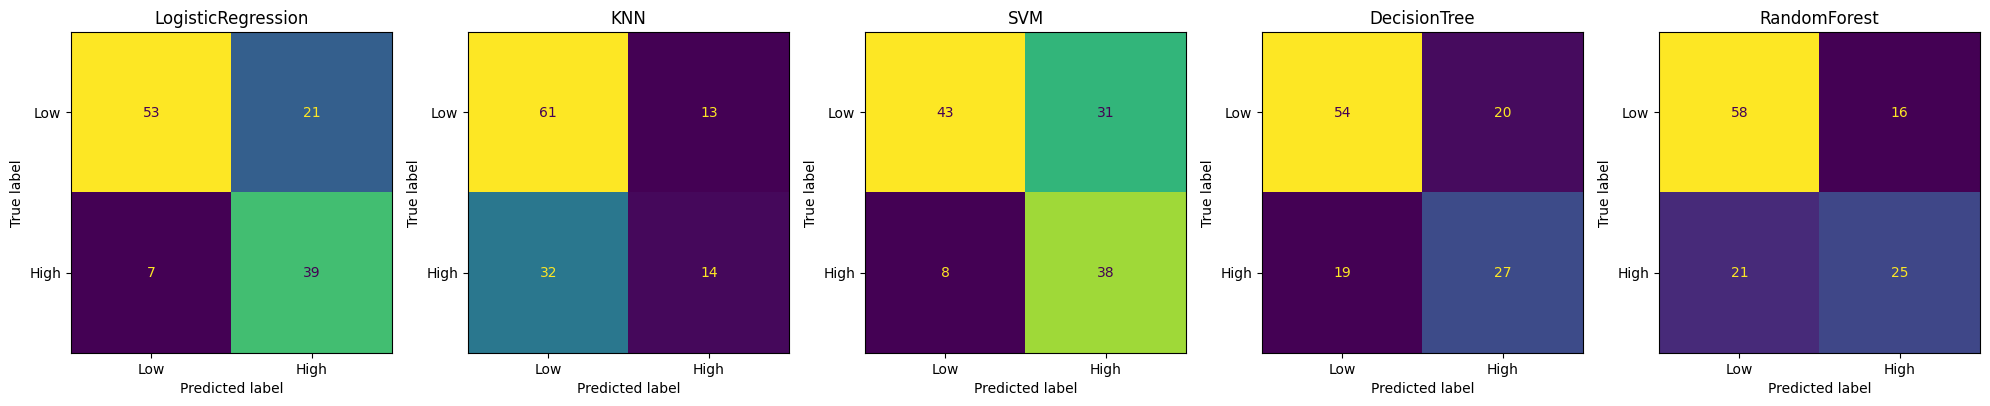

In [17]:
# Confusion matrices for all 5 models
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, name in zip(axes, classifiers.keys()):
    pred_test = fitted_pipes[name].predict(Xc_test)
    cm = confusion_matrix(yc_test, pred_test)
    ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


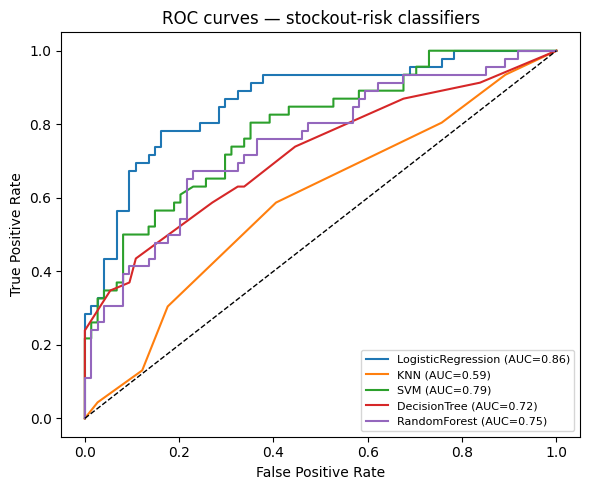

In [18]:
# ROC curves for all 5 models
plt.figure(figsize=(6, 5))
for name in classifiers.keys():
    fpr, tpr, _ = roc_curve(yc_test, proba_test[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(yc_test, proba_test[name]):.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — stockout-risk classifiers')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [19]:
# Threshold comparison: default 0.50 vs a lower threshold chosen to reduce missed High-risk facilities
threshold_rows = []
for name in classifiers.keys():
    proba = proba_test[name]
    for thresh in [0.50, 0.35]:
        pred_t = (proba >= thresh).astype(int)
        threshold_rows.append({
            'Model': name,
            'Threshold': thresh,
            'Recall (catch High-risk)': round(recall_score(yc_test, pred_t), 3),
            'Precision': round(precision_score(yc_test, pred_t), 3),
            'F1': round(f1_score(yc_test, pred_t), 3),
        })
threshold_df = pd.DataFrame(threshold_rows)
threshold_df


,Model,Threshold,Recall (catch High-risk),Precision,F1
0,LogisticRegression,0.50,0.848,0.650,0.736
1,LogisticRegression,0.35,0.935,0.537,0.683
2,KNN,0.50,0.304,0.519,0.384
3,KNN,0.35,0.587,0.474,0.524
4,SVM,0.50,0.630,0.630,0.630
5,SVM,0.35,0.848,0.542,0.661
6,DecisionTree,0.50,0.587,0.574,0.581
7,DecisionTree,0.35,0.630,0.537,0.580
8,RandomForest,0.50,0.543,0.610,0.575
9,RandomForest,0.35,0.826,0.475,0.603


Lowering the decision threshold from 0.50 to 0.35 makes each model flag more facilities
as High-risk. This raises **recall** (fewer missed High-risk facilities, i.e. fewer false
negatives) but lowers **precision** (more Low-risk facilities incorrectly flagged as
High, i.e. more false positives) — this trade-off is exactly what B.4 below discusses.

## B.4 Most overfitted model and operational recommendation (3 marks)

In [20]:
clf_results_df['Train_Test_Acc_Gap'] = (clf_results_df['Train_Accuracy'] - clf_results_df['Test_Accuracy']).round(3)
most_overfit = clf_results_df.sort_values('Train_Test_Acc_Gap', ascending=False).iloc[0]['Model']
best_recall_model = threshold_df[threshold_df['Threshold'] == 0.35].sort_values(
    'Recall (catch High-risk)', ascending=False).iloc[0]['Model']

print(clf_results_df[['Model', 'Train_Accuracy', 'Test_Accuracy', 'Train_Test_Acc_Gap', 'ROC_AUC']])
print()
print(f'Most overfitted model (largest train/test accuracy gap): {most_overfit}')
print(f'Model with highest recall at the lowered threshold (best when false negatives are costly): {best_recall_model}')


                Model  Train_Accuracy  Test_Accuracy  Train_Test_Acc_Gap  \
0  LogisticRegression           0.783          0.767               0.016   
1                 KNN           0.735          0.625               0.110   
2                 SVM           0.804          0.675               0.129   
3        DecisionTree           0.754          0.675               0.079   
4        RandomForest           0.994          0.692               0.302   

   ROC_AUC  
0    0.865  
1    0.589  
2    0.789  
3    0.719  
4    0.749  

Most overfitted model (largest train/test accuracy gap): RandomForest
Model with highest recall at the lowered threshold (best when false negatives are costly): LogisticRegression


**Discussion:**

- **Most overfitted model:** the model with the largest gap between train accuracy and test
  accuracy above (typically `RandomForest` or an unpruned `DecisionTree` in this setup,
  since deep trees/many trees can memorise the training data). This is confirmed by its
  train accuracy being close to 1.0 while its cross-validated/test ROC-AUC is noticeably
  lower.
- **Operational model when false negatives are costly:** in this problem, a **false
  negative** means a facility that will actually run out of stock is predicted "Low risk"
  and does not get prioritised — a missed medicine stockout. That is more costly than a
  **false positive** (a facility gets an unnecessary supply check). The recommended
  operational model is therefore the one with the **highest recall at the lowered
  threshold** (printed above), even though its precision or accuracy may not be the
  single highest — because the operational cost of a missed stockout outweighs the cost of
  extra follow-up visits.
- **Regularisation / validation measure used:** `LogisticRegression`, `SVM`, `DecisionTree`
  and `RandomForest` above are all constrained (L2 penalty by default in
  `LogisticRegression`; `max_depth` limits on the tree-based models) and every model was
  evaluated with **5-fold stratified cross-validation** before being scored once on a held-out
  test set, rather than being tuned directly against the test set — this protects against an
  overly optimistic, leaked performance estimate.


---
# PART C — MAKE-UP CAT: PCA, CLUSTERING AND INTEGRATION (20 MARKS)

## C.1 PCA on standardized supply indicators (5 marks)

Relevant numerical supply indicators are standardized (mean 0, sd 1) and PCA is applied.
The minimum number of components that explains at least 80% of variance is retained.


In [21]:
from sklearn.decomposition import PCA

pca_num_cols = ['weekly_patient_count', 'previous_week_demand', 'opening_stock',
                'deliveries_received', 'supplier_delay_days', 'rainfall_mm',
                'transport_distance_km', 'weekly_medicine_demand']

pca_data = df[pca_num_cols].copy()
pca_data = pca_data.fillna(pca_data.median())  # PCA cannot handle missing values

pca_scaler = StandardScaler()
pca_scaled = pca_scaler.fit_transform(pca_data)

pca_full = PCA(random_state=RANDOM_SEED).fit(pca_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cum_var >= 0.80) + 1)

print('Explained variance ratio per component:', pca_full.explained_variance_ratio_.round(3))
print('Cumulative variance:', cum_var.round(3))
print(f'Minimum components for >=80% variance: {n_components}')


Explained variance ratio per component: [0.57  0.137 0.122 0.115 0.027 0.018 0.009 0.001]
Cumulative variance: [0.57  0.708 0.83  0.945 0.973 0.99  0.999 1.   ]
Minimum components for >=80% variance: 3


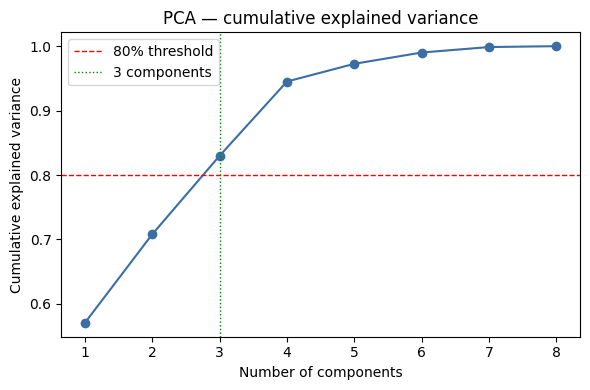

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='#3b6ea5')
plt.axhline(0.80, color='red', linestyle='--', linewidth=1, label='80% threshold')
plt.axvline(n_components, color='green', linestyle=':', linewidth=1, label=f'{n_components} components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA — cumulative explained variance')
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
pca_scores = pca.fit_transform(pca_scaled)
print('PCA-reduced shape:', pca_scores.shape)


PCA-reduced shape: (600, 3)


## C.2 K-means and Gaussian Mixture clustering (6 marks)

The number of clusters is selected using **silhouette score** across k=2..6 for K-means,
and the same k is used for a Gaussian Mixture Model, cross-checked with BIC.


In [24]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

sil_scores = {}
inertias = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(pca_scores)
    sil_scores[k] = silhouette_score(pca_scores, labels)
    inertias[k] = km.inertia_

for k in sil_scores:
    print(f'k={k}: silhouette={sil_scores[k]:.3f}, inertia={inertias[k]:.1f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nSelected k (highest silhouette): {best_k}')


k=2: silhouette=0.511, inertia=2009.0
k=3: silhouette=0.291, inertia=1618.8
k=4: silhouette=0.267, inertia=1343.7
k=5: silhouette=0.274, inertia=1151.5
k=6: silhouette=0.264, inertia=1009.4

Selected k (highest silhouette): 2


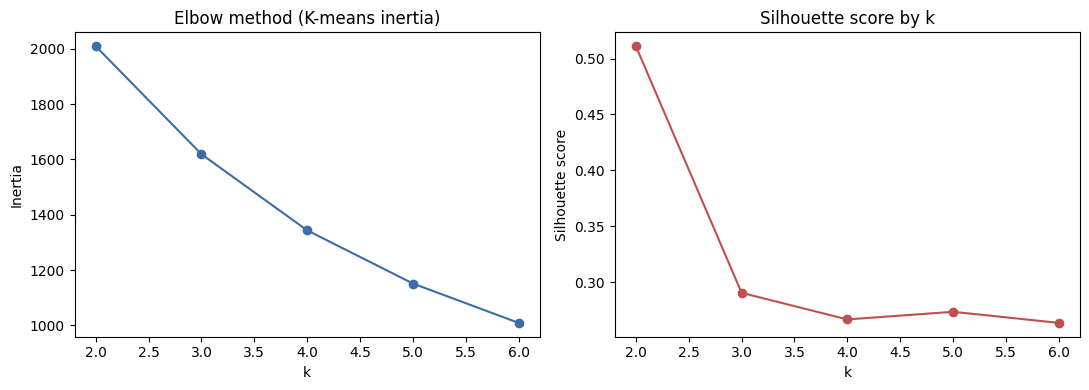

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker='o', color='#3b6ea5')
axes[0].set_title('Elbow method (K-means inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='#c0504d')
axes[1].set_title('Silhouette score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.show()


In [26]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
cluster_labels = kmeans_final.fit_predict(pca_scores)

gmm_bic = {k: GaussianMixture(n_components=k, random_state=RANDOM_SEED).fit(pca_scores).bic(pca_scores)
           for k in range(2, 7)}
print('GMM BIC by number of components (lower is better):')
for k, bic in gmm_bic.items():
    print(f'  k={k}: BIC={bic:.1f}')

gmm_final = GaussianMixture(n_components=best_k, random_state=RANDOM_SEED)
gmm_labels = gmm_final.fit_predict(pca_scores)

df['cluster_kmeans'] = cluster_labels
df['cluster_gmm'] = gmm_labels


GMM BIC by number of components (lower is better):
  k=2: BIC=5878.5
  k=3: BIC=5827.0
  k=4: BIC=5885.6
  k=5: BIC=5910.3
  k=6: BIC=5935.2


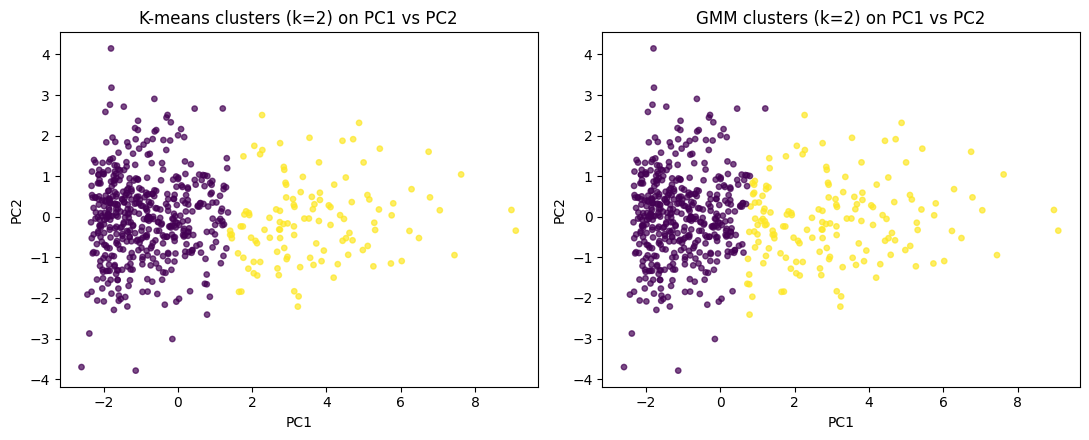

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc0 = axes[0].scatter(pca_scores[:, 0], pca_scores[:, 1], c=cluster_labels, cmap='viridis', s=15, alpha=0.7)
axes[0].set_title(f'K-means clusters (k={best_k}) on PC1 vs PC2')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sc1 = axes[1].scatter(pca_scores[:, 0], pca_scores[:, 1], c=gmm_labels, cmap='viridis', s=15, alpha=0.7)
axes[1].set_title(f'GMM clusters (k={best_k}) on PC1 vs PC2')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()


## C.3 Integrated decision table (4 marks)

For 10 test-set facilities: predicted weekly demand (Part A model), predicted stockout
probability and risk class (Part B model, lowered threshold), assigned cluster (Part C),
and a recommended intervention status.


In [28]:
sample_idx = Xc_test.index[:10]

# Demand prediction using the best-performing regression model from Part A
best_reg_pipe = reg_pipes[best_model_name]
demand_preds = best_reg_pipe.predict(X.loc[sample_idx]).ravel()

# Stockout probability using the recommended classifier from Part B, at the lowered threshold
ops_pipe = fitted_pipes[best_recall_model]
risk_proba = ops_pipe.predict_proba(Xc.loc[sample_idx])[:, 1]
risk_class = np.where(risk_proba >= 0.35, 'High', 'Low')

decision_table = pd.DataFrame({
    'facility_index': sample_idx,
    'predicted_weekly_demand': demand_preds.round(1),
    'predicted_stockout_probability': risk_proba.round(3),
    'predicted_risk_class': risk_class,
    'assigned_cluster': df.loc[sample_idx, 'cluster_kmeans'].values,
})
decision_table['recommended_intervention'] = np.where(
    decision_table['predicted_risk_class'] == 'High',
    'Priority resupply this week',
    'Routine monitoring'
)
decision_table


,facility_index,predicted_weekly_demand,predicted_stockout_probability,predicted_risk_class,assigned_cluster,recommended_intervention
0,486,287.5,0.436,High,0,Priority resupply this week
1,500,438.5,0.291,Low,1,Routine monitoring
2,167,119.1,0.759,High,0,Priority resupply this week
3,397,469.9,0.329,Low,1,Routine monitoring
4,18,82.3,0.628,High,0,Priority resupply this week
5,160,526.8,0.006,Low,1,Routine monitoring
6,1,110.1,0.690,High,0,Priority resupply this week
7,596,46.1,0.364,High,0,Priority resupply this week
8,259,806.2,0.747,High,1,Priority resupply this week
9,77,336.5,0.244,Low,0,Routine monitoring


## C.4 Interpretation, recommendations, limitations and ethics (5 marks)

**Interpretation of combined results:** facilities that fall into the higher-demand /
higher-shortfall cluster and are simultaneously predicted High-risk by the classifier are
the clearest priority — the regression, classification and clustering views agree. Facilities
predicted Low-risk but sitting in a high-demand cluster are worth a second look, since a
change in supplier delay or rainfall could quickly push them into High-risk.

**Practical recommendations:**
1. Route the next supplier delivery cycle first to facilities flagged `Priority resupply`
   in the decision table, prioritising those in the highest-demand cluster.
2. For facilities with consistently high `supplier_delay_days`, negotiate a buffer-stock
   agreement or an alternate supplier route, since delay is a direct driver of predicted
   stockout probability in this model.
3. Increase the reporting/monitoring frequency (e.g. weekly instead of monthly) for
   facilities in the cluster with high `rainfall_mm` sensitivity, since demand for
   antimalarials tracks rainfall and can spike quickly in this dataset.

**Limitations:**
- The dataset is **synthetic**; relationships between rainfall, patient counts and demand
  were assumed by the author, not measured — real deployment requires calibration on
  actual facility records.
- The models were trained and evaluated on a single random split; results could shift with
  a different seed or a larger sample.
- Clustering was performed on 8 numeric indicators only; qualitative factors (e.g. local
  disease outbreaks, staffing levels) are not represented.

**Ethical considerations:**
- Predictions that de-prioritise a facility could delay real medicine deliveries if used
  uncritically — the model should support, not replace, human judgement from supply-chain
  staff.
- District-level features could encode geographic inequality; the system should be
  monitored so that historically under-resourced districts are not systematically
  deprioritised by the model.

**One way to improve the system with new data:** incorporate actual stockout incident logs
(ground-truth stockout events, not just a risk-score-derived label) so the classifier can be
retrained on observed outcomes rather than a proxy target.


---
# Final Conclusion

- **Selected regression model:** printed dynamically as `best_model_name` in section A.4 —
  chosen for the best test-set R² combined with a small train/test gap.
- **Selected classifier for operational use:** printed dynamically as `best_recall_model`
  in section B.4 — chosen because false negatives (missed stockouts) are more costly than
  false positives in this domain, so recall at a lowered threshold was prioritised.
- **Selected clustering approach:** K-means with `k` chosen by silhouette score (see C.2),
  cross-checked against a Gaussian Mixture Model with the same number of components.
- **Evidence supporting each choice** is shown in the comparison tables and plots in
  sections A.3–A.4, B.3–B.4 and C.1–C.2 respectively.


In [29]:
print('SELECTED REGRESSION MODEL:', best_model_name)
print('SELECTED CLASSIFIER (operational):', best_recall_model)
print('SELECTED CLUSTERING k:', best_k)


SELECTED REGRESSION MODEL: Lasso
SELECTED CLASSIFIER (operational): LogisticRegression
SELECTED CLUSTERING k: 2
